<a href="https://colab.research.google.com/github/surayaqis/DataManagement/blob/Final-Report/FinalReport_STQD6324_P166248.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STQD6324 Data Management Final Report**
## **P166248 Suraya Balqis binti Ab.Ghafar**

### **1.0 Introduction**

Superstore dataset is used in this report that contains information about products, sales, and profits to identify key areas of improvement within this fictitious company. The source of this data is from Tableau's sample data. The data consists of 3 tables : Orders, People, Returns. This resembles dataset real industry's data of B2B or B2C Sales dataset where dataset are multi tables, from various systems, ERP or sources. The dataset consists of sales order transaction data from 2023 to 2026 assuming the year has ended.

This report shows data management and analytics process using HDFS - Apache Hive and analysis via Google Colab - Python.

It includes the following contents:

*   Data Cleaning
*   Data Visualizations
*   Insights & Explanations
*   Recommendations
*   Conclusion
*   References

The dataset was split into 3 CSVs for data cleaning purpose via Apache Hive.

### **2.0 Data Cleaning**



**2.1   Import data to HDFS**
- the three CSV files (orders.csv, people.csv, return.csv) are uploaded to HDFS Files view
      ![Upload csv files into Hadoop]( https://photos.fife.usercontent.google.com/pw/AP1GczOc6te8Mbo_mo2eYaUPkZSSteuTBRPkKt4F4V8xPYD66w0A3AO2S6yu=w1526-h360-s-no-gm?authuser=0)
   




**2.2   Import data from HDFS path to Hive**
- in Hive View, all three CSV files imported from HDFS Path
- orders_csv : column type of sales, discount and profit updated to DOUBLE, quantity to INT
![import from HDFS path]( https://photos.fife.usercontent.google.com/pw/AP1GczNQNejz6HPQAKJtXiP6fLRZjaK5DAqAwdeD9O1ehMM0grTrW_Ya5INO=w1526-h720-s-no-gm?authuser=0)





**2.3 Data Cleaning & Preprocessing**

**> 2.3.1 orders_clean**
- trim whitespace of STRING column.
- convert order_date and ship_date to Date format.
- include logical function if there's blank in postal_code, then NULL.
- remove duplicates if there's any, to ensure dataset has unique primary keys.
- this table act as a fact table.
![orders_clean](https://photos.fife.usercontent.google.com/pw/AP1GczO1wiVBw7E6c3nT9XClwI9jJQXfJx57UpzeeRm9jYw3YS2Ysm4mz-bF=w944-h613-s-no-gm?authuser=0)


**> 2.3.2 people_clean & returns_clean**
- trim whitespace of STRING column.
![people_clean](https://photos.fife.usercontent.google.com/pw/AP1GczMVwbDAxFpzQw6bhoiHOhama7-E3t0NSOAFoA73x8REu9Cy45bIdIa4=w763-h526-s-no-gm?authuser=0)

**> 2.3.4 dim_product**
- One product_id may have more than one product_name. The data was reviewed to check if they are the same product or different, found that the product are clearly different products based on the names.
![product name conflict](https://photos.fife.usercontent.google.com/pw/AP1GczNLLDZAQ1fm041FxjpjQxiyX_uSEYTI66XT1MLQDPCLDMqXRF4l0I4P=w973-h916-s-no-gm?authuser=0)

- Hence a new table is created to establish a new column called “product_key” so that each product gets its own unique key.
![dim_product](https://photos.fife.usercontent.google.com/pw/AP1GczOnqC1jBojHR5svfhEp03beNhUA2I4bxBIQvtTPiwQtyihiSjEV9gva=w660-h407-s-no-gm?authuser=0)

- Sample of dim_product table with product_key:
![dim_product sample](https://photos.fife.usercontent.google.com/pw/AP1GczP0CLX930JgIOLzSQy4N6z4E06Wscpxrg7cgubQ8KcyUcZOj2rrgL4Z=w873-h821-s-no-gm?authuser=0)

- Data Quality check.
The gap between total_products and distinct_ids, 32 are the number of duplicate name products and have been segregated by the product_key.
![qa check1](https://photos.fife.usercontent.google.com/pw/AP1GczMesmxuatMpuQDQweh3qr1Ifg4IDskczFH0zgY5wJ7ffXwyxQjPnzsC=w212-h60-s-no-gm?authuser=0)

- Data Quality check on NULLs value. This is to ensure there is no NULLs in the data, as NULLs indicate rows where a numeric or date cast failed.
![qa check2](https://photos.fife.usercontent.google.com/pw/AP1GczMqALApfbKYKXmnGEZ54Z0nT8R0a48SLe7kshtaCR45iz9aS0wZ00d6=w329-h75-s-no-gm?authuser=0)

**> 2.3.5 orders_partitioned**
- Hive stores each partition as a separate HDFS directory. A query that filters on the partition column (e.g. WHERE order_year = 2026) reads ONLY that directory instead of scanning the whole table. This is "partition pruning". It cuts I/O, speeds up queries, and makes large tables manageable. ORC adds columnar storage + compression + predicate pushdown.
![partitioned](https://photos.fife.usercontent.google.com/pw/AP1GczN90vWGUXZPseoHx57F_DOY7NvaL1qEzwoMvNq2feidp6P3E0v8k1Yl=w1353-h904-s-no-gm?authuser=0)

**> 2.3.6 orders_merged**
- This query consolidates *order, manager,* and *return* table into a unified table ***orders_merged*** using left joins. This enabled comprehensive analysis using a single dataset.
![merged table](https://photos.fife.usercontent.google.com/pw/AP1GczMZwC-IS7vNKs0KDxzBbGCABjDyfivc32fQiQ9zvz957Sfset7e4025=w1358-h495-s-no-gm?authuser=0)

**> 2.3.7 Export as csv to local path**
- The unified table ***orders_merged*** is then exported as csv to local path for further analysis via Python (Google Colab)





### **3.0 Exploratory Data Analysis & Data Visualization**

In [ ]:
# --- Section setup: libraries, data, derived fields, plotting theme ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

In [ ]:
# Load the merged orders data from the specified path
file_path = '/content/drive/MyDrive/Colab Notebooks/orders_merged.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,orders_merged.id,orders_merged.order_id,orders_merged.order_date,orders_merged.ship_date,orders_merged.ship_mode,orders_merged.customer_id,orders_merged.customer_name,orders_merged.segment,orders_merged.country_region,orders_merged.city,...,orders_merged.sub_category,orders_merged.product_name,orders_merged.sales,orders_merged.quantity,orders_merged.discount,orders_merged.profit,orders_merged.order_year,orders_merged.order_month,orders_merged.manager,orders_merged.returned
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"""Message Book, Wirebound, Four 5 1/2"""" X 4"""" F...",16.448,2,0.2,5.5512,2023,1,Roxanne Rodriguez,No
1,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112,2023,1,Fred Suzuki,No
2,11,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Paper,Southworth 25% Cotton Granite Paper & Envelopes,6.540,1,0.0,3.0084,2023,1,Fred Suzuki,No
3,12,US-2023-130813,2023-01-06,2023-01-08,Second Class,LS-17230,Lycoris Saunders,Consumer,United States,Los Angeles,...,Paper,Xerox 225,19.440,3,0.0,9.3312,2023,1,Sadie Pawthorne,No
4,13,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,Phones,Wireless Extenders zBoost YX545 SOHO Signal Bo...,755.960,4,0.0,204.1092,2023,1,Fred Suzuki,No


In [ ]:
# Remove 'orders_merged.' prefix from column names
df.columns = df.columns.str.replace('orders_merged.', '', regex=False)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"]  = pd.to_datetime(df["ship_date"],  errors="coerce")
df["is_returned"]   = df["returned"].eq("Yes")
df["profit_margin"] = df["profit"] / df["sales"]
df["ship_days"]     = (df["ship_date"] - df["order_date"]).dt.days

# Display the updated column names and the first few rows to verify
print("Updated column names:", df.columns.tolist())
display(df.head())

Updated column names: ['id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country_region', 'city', 'state_province', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'order_year', 'order_month', 'manager', 'returned', 'is_returned', 'profit_margin', 'ship_days']


,id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,...,quantity,discount,profit,order_year,order_month,manager,returned,is_returned,profit_margin,ship_days
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,2,0.2,5.5512,2023,1,Roxanne Rodriguez,No,False,0.3375,4
1,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,4,0.0,0.3112,2023,1,Fred Suzuki,No,False,0.0100,4
2,11,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,1,0.0,3.0084,2023,1,Fred Suzuki,No,False,0.4600,4
3,12,US-2023-130813,2023-01-06,2023-01-08,Second Class,LS-17230,Lycoris Saunders,Consumer,United States,Los Angeles,...,3,0.0,9.3312,2023,1,Sadie Pawthorne,No,False,0.4800,2
4,13,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,4,0.0,204.1092,2023,1,Fred Suzuki,No,False,0.2700,4


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0]) # Display only columns with missing values

,0


In [ ]:
# Calculate summary statistics for numeric columns
summary_stats = df.describe()
display(summary_stats)

,id,order_date,ship_date,sales,quantity,discount,profit,order_year,order_month,profit_margin,ship_days
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417,2024.720129,7.811850,0.122218,3.961350
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2023.000000,1.000000,-2.750000,0.000000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800,2024.000000,5.000000,0.075000,3.000000
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000,2025.000000,9.000000,0.270000,4.000000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925,2026.000000,11.000000,0.362500,5.000000
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2026.000000,12.000000,0.500000,11.000000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115,1.125611,3.295915,0.464890,1.742829


In [ ]:
# Shared palette
PALETTE = {"navy":"#1f3b57","teal":"#2a9d8f","amber":"#e9a23b","rust":"#c0563f",
           "slate":"#6b7a8f","green":"#3a9d54","red":"#c0392b"}
CAT_COLOURS = {"Office Supplies":PALETTE["teal"],"Technology":PALETTE["navy"],
               "Furniture":PALETTE["amber"]}

#### **3.1 Annual Sales - Profit & Margin**

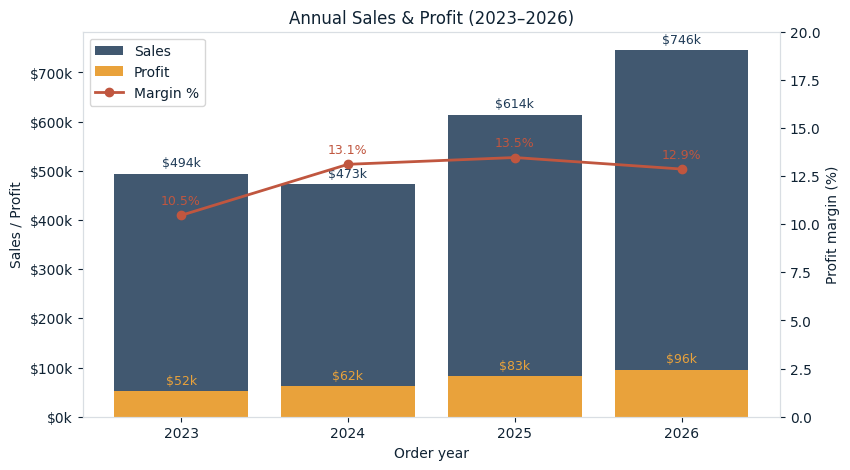

In [ ]:
yearly = df.groupby("order_year").agg(sales=("sales","sum"),
                                      profit=("profit","sum")).reset_index()
yearly["margin"] = yearly["profit"]/yearly["sales"]

fig, ax1 = plt.subplots(figsize=(9,5))
x = yearly["order_year"].astype(str)
ax1.bar(x, yearly["sales"], color=PALETTE["navy"], alpha=0.85, label="Sales")
ax1.bar(x, yearly["profit"], color=PALETTE["amber"], label="Profit")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
ax1.set_ylabel("Sales / Profit"); ax1.set_xlabel("Order year")
ax1.set_title("Annual Sales & Profit (2023–2026)")
# Add data labels for sales
for i, sale in enumerate(yearly["sales"]):
    ax1.annotate(f'${sale/1e3:,.0f}k', (x[i], sale), textcoords="offset points", xytext=(0,5), ha='center', color=PALETTE["navy"], fontsize=9)
# Add data labels for profit
for i, profit in enumerate(yearly["profit"]):
    ax1.annotate(f'${profit/1e3:,.0f}k', (x[i], profit), textcoords="offset points", xytext=(0,5), ha='center', color=PALETTE["amber"], fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, yearly["margin"]*100, color=PALETTE["rust"], marker="o", lw=2, label="Margin %")
ax2.set_ylabel("Profit margin (%)"); ax2.set_ylim(0,20)
for xi,m in zip(x, yearly["margin"]*100):
    ax2.annotate(f"{m:.1f}%", (xi,m), textcoords="offset points", xytext=(0,8),
                 ha="center", color=PALETTE["rust"], fontsize=9)
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left")

### Discussion: Annual Sales - Profit & Margin

Sales increased from 494k in 2023, to 746k in 2026. Profit nearly doubled from 53k in 2023 to 96k in 2026. However profit margin rose high in 2024 (13.1%) and 2025 (13.5%) but shows a decline in 2026 (12.9%)

This shows healthy sales growth from 2023. The profit margin shows the business can improve profitability over the years. A decline of 2026 margin is warning sign, the revenue came at lower profitatbility. This raises question of whether growth is part-funded by discounting.

#### **3.2 Monthly Seasonality**

Text(0.5, 14.722222222222216, '')

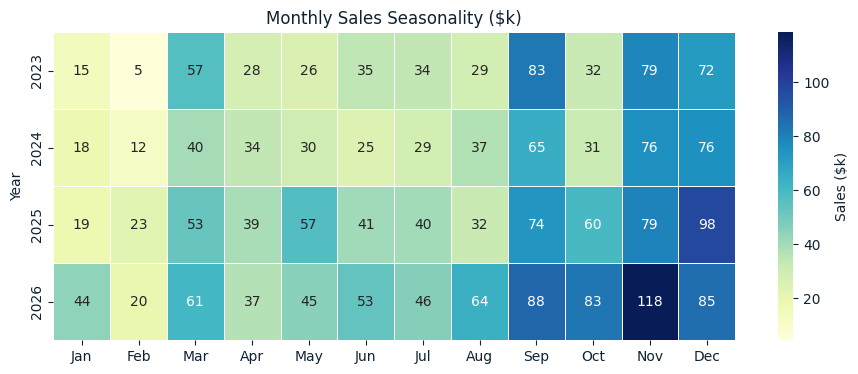

In [ ]:
month_pivot = (df.pivot_table(index="order_year", columns="order_month",
                              values="sales", aggfunc="sum")/1e3)
month_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(11,4))
sns.heatmap(month_pivot, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label":"Sales ($k)"}, linewidths=.5)
plt.title("Monthly Sales Seasonality ($k)"); plt.ylabel("Year"); plt.xlabel("")

### Discussion: Monthly Seasonality

This shows demand is seasonaly strong and similar pattern repeats every year. High demand is observed on November, December, and September. the lowest demand would be in February.

This is classic B2B or retail seasonality where there is a year-end surge possibly due to holiday demand or budget flush. As the patterns are similar across all four years, this can be an indicator to the business in terms of inventory and operational resoruce, can be ramped ahead of Sep-Dec peak.

#### **3.3 Category & Sub-Category Profitability**

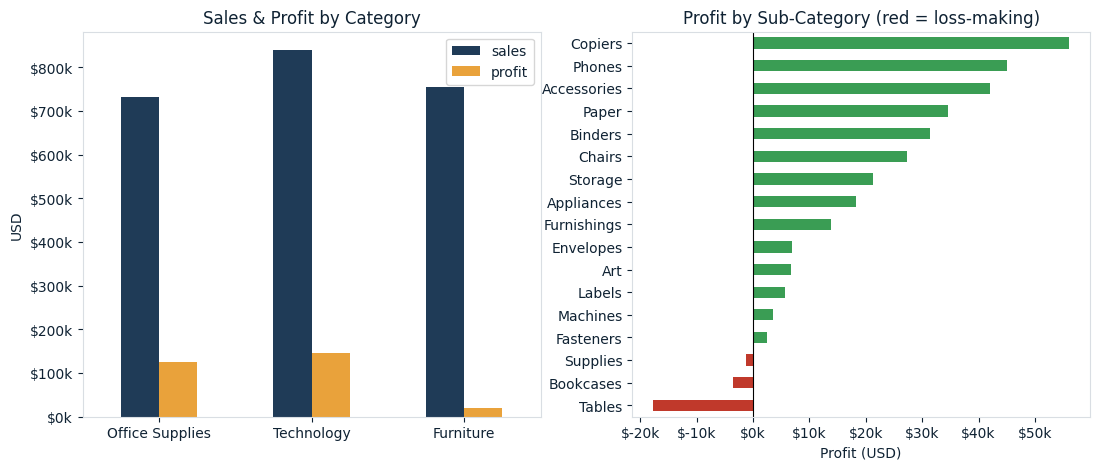

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
cat = df.groupby("category").agg(sales=("sales","sum"),
                                 profit=("profit","sum")).reindex(CAT_COLOURS.keys())
cat[["sales","profit"]].plot(kind="bar", ax=axes[0],
                             color=[PALETTE["navy"],PALETTE["amber"]])
axes[0].set_title("Sales & Profit by Category"); axes[0].set_ylabel("USD"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
axes[0].tick_params(axis="x", rotation=0)

sub = df.groupby("sub_category")["profit"].sum().sort_values()
colours = [PALETTE["red"] if v<0 else PALETTE["green"] for v in sub.values]
sub.plot(kind="barh", ax=axes[1], color=colours)
axes[1].axvline(0, color="black", lw=.8)
axes[1].set_title("Profit by Sub-Category (red = loss-making)")
axes[1].set_xlabel("Profit (USD)"); axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))

### Discussion: Category & Sub-Category Profitability

Technology has the highest sales followed by office supplies and furnitures. There are 3 sub-categories that are in loss: Supplies, Bookcases and Tables. These three are part of the Furniture sales with negative profits. This needs to investigated further on why there is a loss.

#### **3.4 Region & Segment Performance**

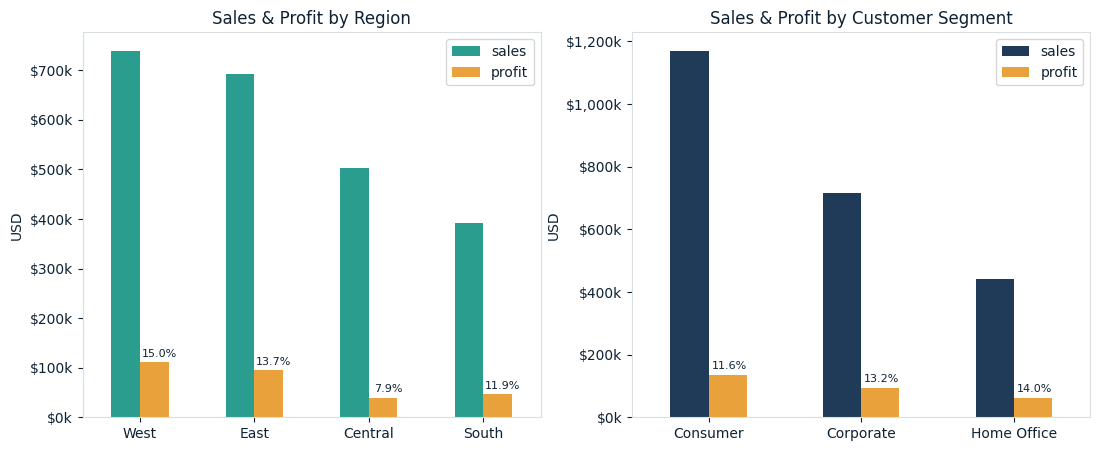

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
reg = df.groupby("region").agg(sales=("sales","sum"),
                               profit=("profit","sum")).sort_values("sales", ascending=False)
reg["margin"] = reg["profit"]/reg["sales"]
reg[["sales","profit"]].plot(kind="bar", ax=axes[0], color=[PALETTE["teal"],PALETTE["amber"]])
axes[0].set_title("Sales & Profit by Region"); axes[0].set_ylabel("USD"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
axes[0].tick_params(axis="x", rotation=0)
for i,m in enumerate(reg["margin"]):
    axes[0].annotate(f"{m:.1%}", (i, reg["profit"].iloc[i]), textcoords="offset points",
                     xytext=(14,4), ha="center", fontsize=8)

seg = df.groupby("segment").agg(sales=("sales","sum"),
                                profit=("profit","sum")).sort_values("sales", ascending=False)
seg["margin"] = seg["profit"]/seg["sales"] # Calculate margin for segments
seg[["sales","profit"]].plot(kind="bar", ax=axes[1], color=[PALETTE["navy"],PALETTE["amber"]])
axes[1].set_title("Sales & Profit by Customer Segment"); axes[1].set_ylabel("USD"); axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
axes[1].tick_params(axis="x", rotation=0)
# Add margin annotations for the customer segment chart
for i,m in enumerate(seg["margin"]):
    axes[1].annotate(f"{m:.1%}", (i, seg["profit"].iloc[i]), textcoords="offset points",
                     xytext=(15,4), ha="center", fontsize=8)

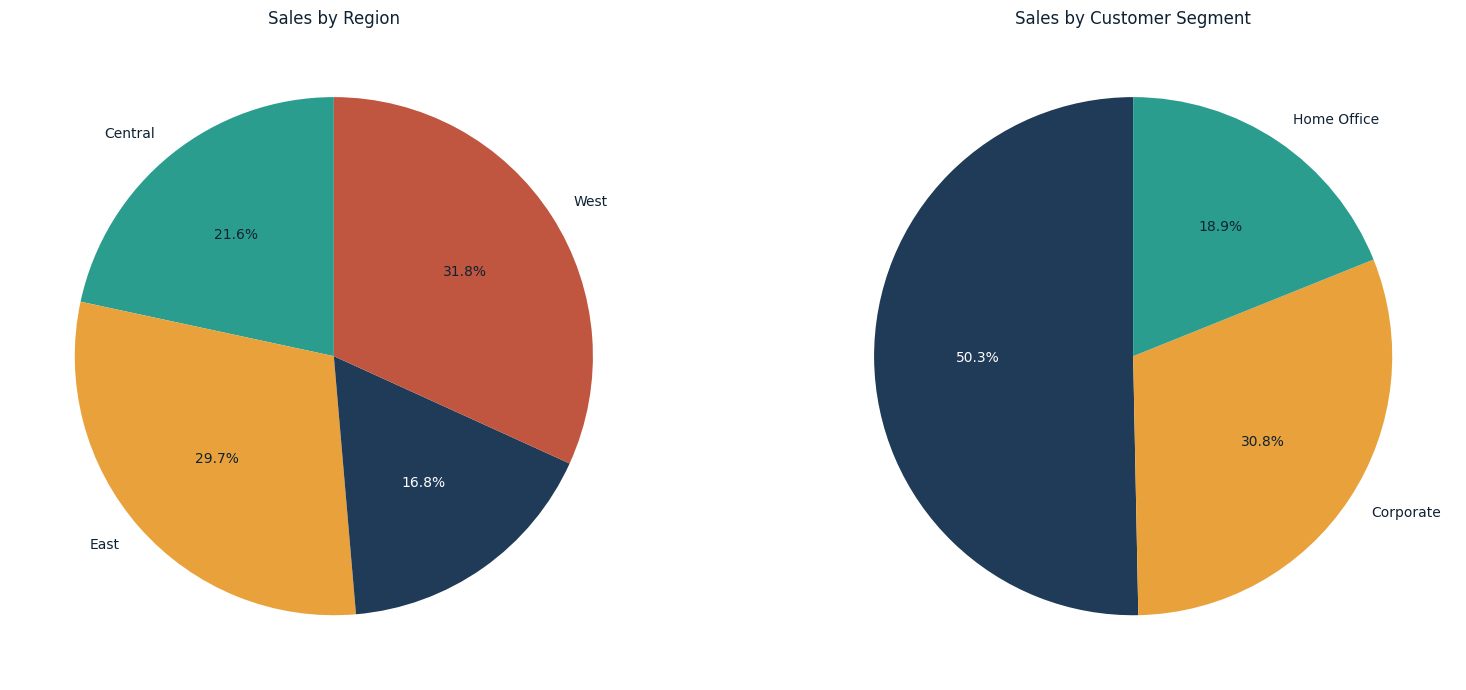

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart for Sales by Region
sales_by_region = df.groupby('region')['sales'].sum()
wedges_region, texts_region, autotexts_region = axes[0].pie(sales_by_region, labels=sales_by_region.index, autopct='%1.1f%%', startangle=90, colors=[PALETTE['teal'], PALETTE['amber'], PALETTE['navy'], PALETTE['rust']])
axes[0].set_title('Sales by Region')

# Find the index of 'South' in the region labels and set its text color to white
for i, region_label in enumerate(sales_by_region.index):
    if region_label == 'South':
        texts_region[i].set_color('white')
        autotexts_region[i].set_color('white')

# Pie chart for Sales by Customer Segment
sales_by_segment = df.groupby('segment')['sales'].sum()
wedges_segment, texts_segment, autotexts_segment = axes[1].pie(sales_by_segment, labels=sales_by_segment.index, autopct='%1.1f%%', startangle=90, colors=[PALETTE['navy'], PALETTE['amber'], PALETTE['teal']])
axes[1].set_title('Sales by Customer Segment')

# Find the index of 'Consumer' in the segment labels and set its text color to white
for i, segment_label in enumerate(sales_by_segment.index):
    if segment_label == 'Consumer':
        texts_segment[i].set_color('white')
        autotexts_segment[i].set_color('white')

plt.tight_layout()
plt.show()

### Discussion: Region & Customer Segment Performance

West and East part lead on sales with 31.8% and 29.7% respectively. Overall, sales are distributed fairly across four regions. For margins, South shows a better margin although with lower Sales than the Central. Across segments, consumer generates most of the revenues but with thinnest margin (11.6%). Meanwhile Home Office generates lowest revenue but the most profitable (14.0%).

Sales and profit rank do not match. Central sells well but converts poorly. The segment pattern suggests that Home Office and Corporate would lift blended margin although Consumer volume remains as the revenue backbone. This shows that territory and segment strategy should be considered by margin and not sales alone.

#### **3.5 The Discount–Profit Relationship**

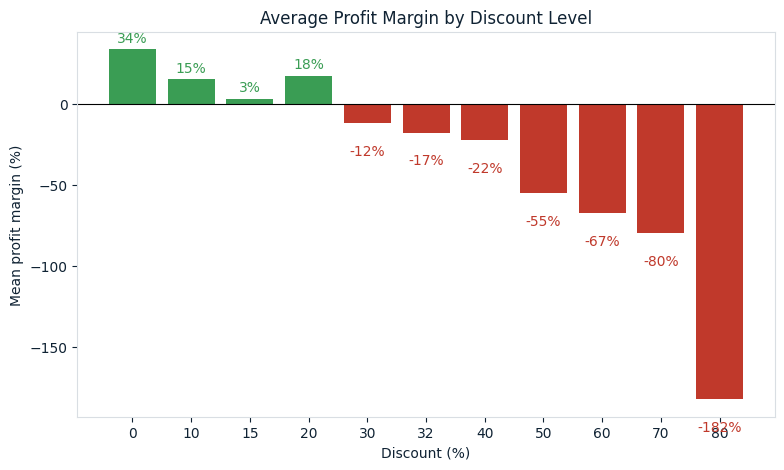

In [ ]:
disc = (df.groupby("discount").agg(profit=("profit","mean"),
                                   margin=("profit_margin","mean"),
                                   n=("profit","size")).reset_index())
disc = disc[disc["n"]>=20]
fig, ax = plt.subplots(figsize=(9,5))
colours = [PALETTE["green"] if v>=0 else PALETTE["red"] for v in disc["margin"]]
bars = ax.bar((disc["discount"]*100).astype(int).astype(str), disc["margin"]*100, color=colours)
ax.axhline(0, color="black", lw=.8)
ax.set_title("Average Profit Margin by Discount Level")
ax.set_xlabel("Discount (%)"); ax.set_ylabel("Mean profit margin (%)")

# Add margin labels
for bar in bars:
    yval = bar.get_height()
    ax.annotate(f'{yval:.0f}%', xy=(bar.get_x() + bar.get_width() / 2, yval),
                xytext=(0, 3 if yval >= 0 else -15), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom' if yval >= 0 else 'top',
                color=PALETTE["green"] if yval >=0 else PALETTE["red"])

### Discussion: The Discount–Profit Relationship

This chart averages each line's percentage margin.
Margin is around 34% at full price and stays positive through a 20% discount. The margin declines sharply negative from 30% discount onwards and fails to 80% at deepest level.

Every discount point comes straight out of margin. Past 25%, the price falls below cost and the store loses money. A discount ceiling near 20% is the highest-value single intervention.

#### **3.6 Returns Analysis**

Text(0, 0.5, 'Return rate')

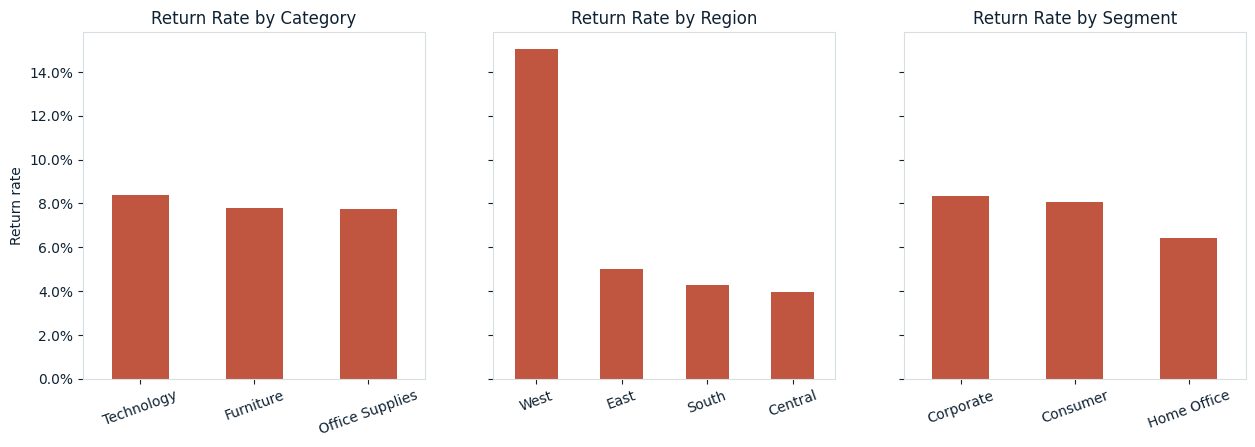

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4.5), sharey=True)
for ax,col,title in zip(axes, ["category","region","segment"], ["Category","Region","Segment"]):
    rr = df.groupby(col)["is_returned"].mean().sort_values(ascending=False)
    rr.plot(kind="bar", ax=ax, color=PALETTE["rust"])
    ax.set_title(f"Return Rate by {title}")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Return rate")

### Discussion: Returns Analysis

Overall return rate is 7.8% but it is unevenly spread. By region, West stands out the most at ~15% return rate versus ~4% at other regions. By category, the return rate is normally distributed about ~8% while by Segment, Corporate and Consumer's return rate is highest at ~8%

West shows a triple return rate as compared to other regions. Although West is also the best-margin region, this could be potentially a risk where returns could decrease the profit. This usually signals a product quality problem rather than a price problem. Overall, return rate is highly contributed by West region, hence it is priority to investigate further on how to reduce the return rate as this indicates the company's product quality issue.

#### **3.7 Regional Manager Performance**

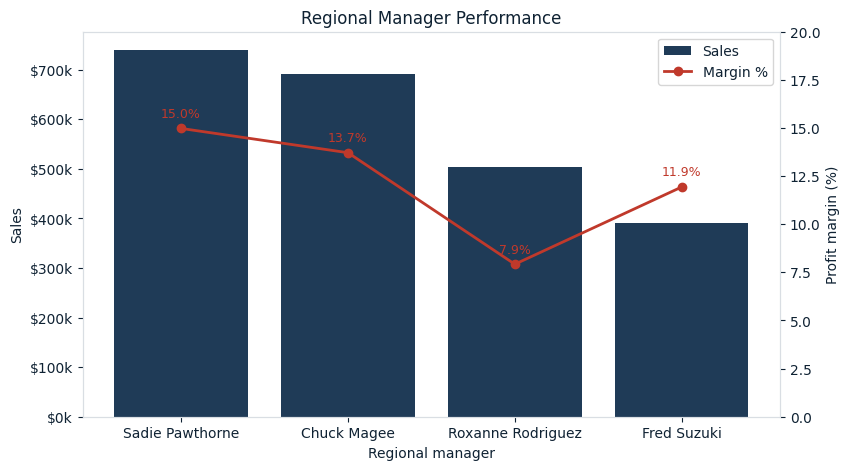

In [ ]:
mgr = (df.groupby("manager")
         .agg(sales=("sales","sum"), profit=("profit","sum"),
              orders=("order_id","nunique"), return_rate=("is_returned","mean"))
         .reset_index())
mgr["margin"] = mgr["profit"]/mgr["sales"]
mgr = mgr.sort_values("sales", ascending=False)
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(mgr["manager"], mgr["sales"], color=PALETTE["navy"], label="Sales")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
ax1.set_ylabel("Sales"); ax1.set_xlabel("Regional manager"); ax1.set_title("Regional Manager Performance")
ax2 = ax1.twinx()
ax2.plot(mgr["manager"], mgr["margin"]*100, color=PALETTE["red"], marker="o", lw=2, label="Margin %")
ax2.set_ylabel("Profit margin (%)"); ax2.set_ylim(0,20)
for x_,m in zip(mgr["manager"], mgr["margin"]*100):
    ax2.annotate(f"{m:.1f}%", (x_,m), textcoords="offset points", xytext=(0,8),
                 ha="center", color=PALETTE["red"], fontsize=9)
h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2,l1+l2, loc="upper right")

### Discussion: Regional Manager Performance

Sadie from West leads on both sales (740k) and profit margin (15%). Fred from South has the lowest sales but a higher profit margin as compared to Roxanne from Central.

Each manager owns a region so this reframes it as accountability. Sadie's strong commercial results are undercut by returns. Roxanne's clean returnes but weak margin point to over-discounting or higher costs in Central. With only four managers, these are directional signals, not statistically robust comparisons.

#### **3.8 Top 10 States by Sales**

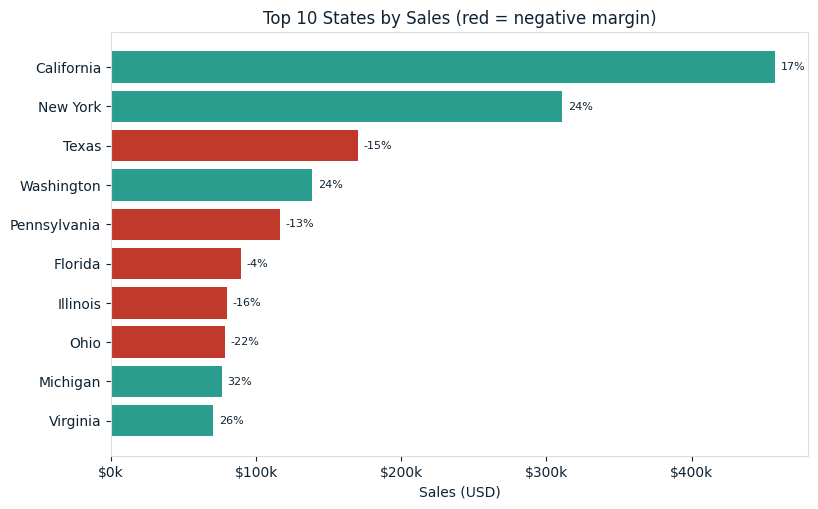

In [ ]:
st = (df.groupby("state_province")
        .agg(sales=("sales","sum"), profit=("profit","sum")).reset_index())
st["margin"] = st["profit"]/st["sales"]
top = st.sort_values("sales", ascending=False).head(10).sort_values("sales")
fig, ax = plt.subplots(figsize=(9,5.5))
colours = [PALETTE["red"] if m<0 else PALETTE["teal"] for m in top["margin"]]
ax.barh(top["state_province"], top["sales"], color=colours)
ax.set_title("Top 10 States by Sales (red = negative margin)"); ax.set_xlabel("Sales (USD)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:,.0f}k"))
for i,(s,m) in enumerate(zip(top["sales"], top["margin"])):
    ax.annotate(f"{m:.0%}", (s,i), textcoords="offset points", xytext=(4,0),
                va="center", fontsize=8)

### Discussion: Top 10 States by Sales

California (\$458k, 16.7%) and New York (\$311k, 23.8%) are the profitable states. Five of the top ten states by sales lose money as shown in red with negative margin: Texas
(−15.1%), Ohio (−21.7%), Illinois (−15.7%),
Pennsylvania (−13.4%) and Florida (−3.8%). Smaller states such as Michigan (32.1%) and Virginia (26.3%) are highly profitable.

High sales clearly do not guarantee profit. Several of the largest markets are being served at a substantial loss. Texas is an obvious scenario where large volume sold at a
heavy negative margin, which is almost certainly the geographic footprint of the discount
problem. These five states are where pricing discipline would recover the most profit, and they can be addressed without touching the genuinely profitable markets.
This chart turns the abstract discount finding into a concrete, location-specific
action list.

#### **3.9 Ship Mode Mix & Delivery Speed**

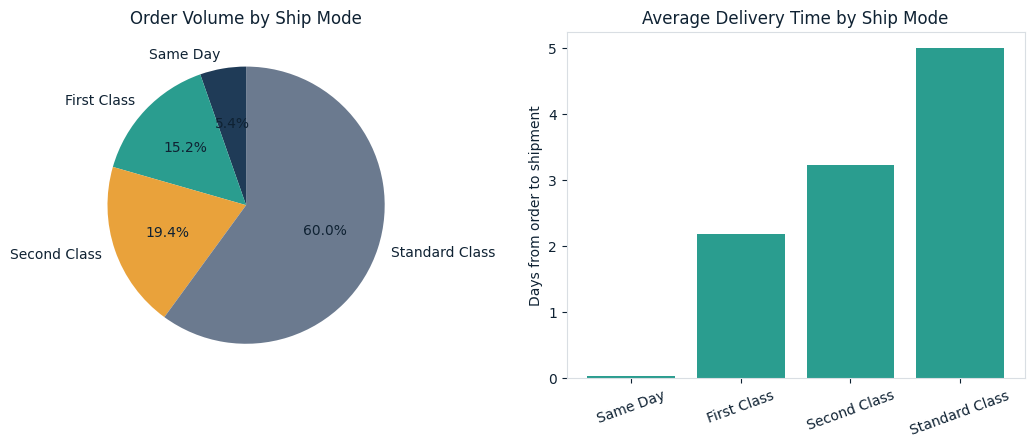

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
ship_order = ["Same Day","First Class","Second Class","Standard Class"]
sm = df["ship_mode"].value_counts().reindex(ship_order)
axes[0].pie(sm, labels=sm.index, autopct="%1.1f%%", startangle=90,
            colors=[PALETTE["navy"],PALETTE["teal"],PALETTE["amber"],PALETTE["slate"]])
axes[0].set_title("Order Volume by Ship Mode")
sd = df.groupby("ship_mode")["ship_days"].mean().reindex(ship_order)
axes[1].bar(sd.index, sd.values, color=PALETTE["teal"])
axes[1].set_title("Average Delivery Time by Ship Mode")
axes[1].set_ylabel("Days from order to shipment"); axes[1].tick_params(axis="x", rotation=20)

### Discussion: Ship Mode Mix & Delivery Speed

Standard Class dominates over volume with 60% followed by Second Class (19%) and First Class (15%). This shows most customers accept the cheapest, and slowest shipping option which is favorable for margin. It keeps fulfilment costs down. The small % of Same Day suggest limited willingness to pay for speed. Operationally, this mix distribution is healthy needs no urgent action. This confirms that shipping is not a hidden cost pressure point. The profit issues identified sit with pricing and returns rather than the logistics.

In [ ]:
# --- Executive theme & shared figures --------------------------------
from matplotlib.patches import FancyBboxPatch

INK,NAVY,TEAL,GOLD,RED,GREY,CARD,BG = ("#0f2233","#1b3a5b","#2a9d8f","#c9962f",
                                       "#b5402f","#9aa6b2","#f4f1ea","#ffffff")
plt.rcParams.update({
    "figure.facecolor":BG,"axes.facecolor":BG,"savefig.facecolor":BG,
    "savefig.dpi":170,"text.color":INK,"axes.edgecolor":"#d9dee3",
    "axes.labelcolor":INK,"xtick.color":INK,"ytick.color":INK,"axes.grid":False,
})
def money(v):
    a=abs(v)
    if a>=1e6: return f"${v/1e6:.2f}M"
    if a>=1e3: return f"${v/1e3:.0f}k"
    return f"${v:,.0f}"

tot_sales, tot_profit = df.sales.sum(), df.profit.sum()
y = df.groupby("order_year").agg(s=("sales","sum"), p=("profit","sum"), rr=("is_returned","mean"))
y["m"]=y.p/y.s
cagr      = (y.s.iloc[-1]/y.s.iloc[0])**(1/3)-1
sales_yoy = y.s.iloc[-1]/y.s.iloc[-2]-1

#### **3.10 Profit Waterfall Chart — Value at Risk**

Text(1.55, 394052.100368, 'Recovering even half of this\nleak ≈ +23% to net profit')

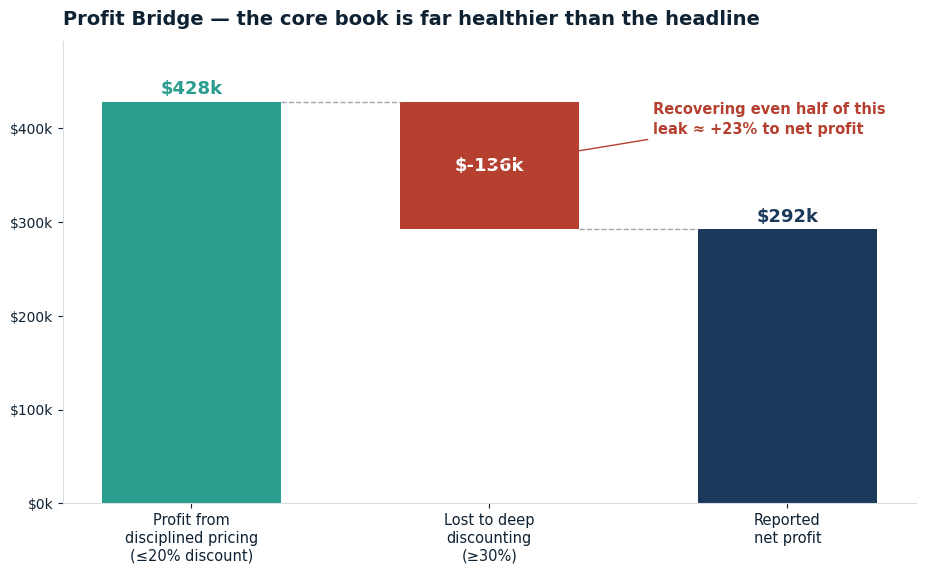

In [ ]:
healthy = df[df.discount<=0.20].profit.sum()
drain   = df[df.discount>=0.30].profit.sum()
actual  = tot_profit
fig, ax = plt.subplots(figsize=(11,6))
labels = ["Profit from\ndisciplined pricing\n(\u226420% discount)",
          "Lost to deep\ndiscounting\n(\u226530%)","Reported\nnet profit"]
ax.bar(0, healthy, color=TEAL, width=0.6)
ax.bar(1, healthy-actual, bottom=actual, color=RED, width=0.6)
ax.bar(2, actual, color=NAVY, width=0.6)
ax.plot([0.3,0.7],[healthy,healthy], color=GREY, lw=1, ls="--")
ax.plot([1.3,1.7],[actual,actual], color=GREY, lw=1, ls="--")
ax.text(0, healthy+8000, money(healthy), ha="center", fontsize=13, fontweight="bold", color=TEAL)
ax.text(1, healthy-(healthy-actual)/2, money(drain), ha="center", va="center", fontsize=13, fontweight="bold", color="white")
ax.text(2, actual+8000, money(actual), ha="center", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xticks([0,1,2]); ax.set_xticklabels(labels, fontsize=10.5); ax.set_ylim(0, healthy*1.15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"${v/1e3:.0f}k"))
ax.set_title("Profit Bridge — the core book is far healthier than the headline", fontsize=14, fontweight="bold", loc="left", pad=12)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.annotate("Recovering even half of this\nleak \u2248 +23% to net profit",
            xy=(1, actual+(healthy-actual)/2), xytext=(1.55, healthy*0.92),
            fontsize=10.5, color=RED, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=RED), linespacing=1.4)

### Discussion: Profit Bridge

This waterfall chart reframes the entire profit story. Core business is healthy. -136k is not an unavoidable cost but it is a recoverable leak. Recovering half of it would lift the net profit around 23%. The is the most persuasive single argument for a discount cap. Deep discounting that is with more than 30% hands 136k, leaving the 292k reported profit.

#### **3.11 Strategic Growth–Margin Matrix**

Text(0.99, 0.01, 'bubble size = total sales')

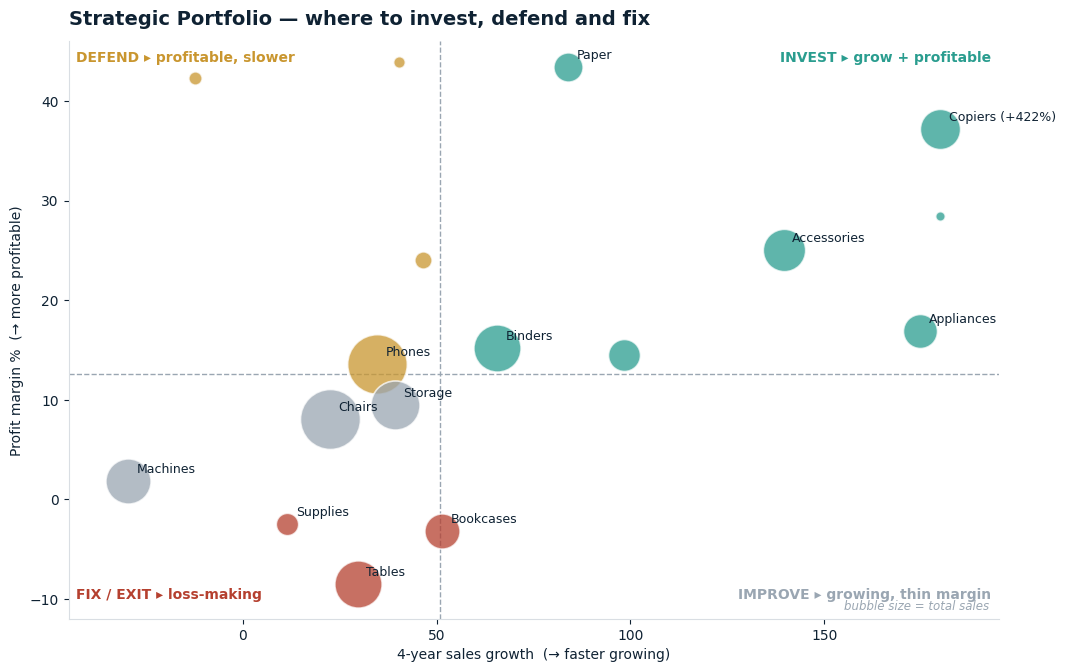

In [ ]:
g23 = df[df.order_year==2023].groupby("sub_category").sales.sum()
g26 = df[df.order_year==2026].groupby("sub_category").sales.sum()
s = df.groupby("sub_category").agg(sales=("sales","sum"), profit=("profit","sum"))
s["margin"]=(s.profit/s.sales)*100; s["growth"]=((g26/g23)-1)*100
comp_margin = tot_profit/tot_sales*100
comp_growth = (y.s.iloc[-1]/y.s.iloc[0]-1)*100
s["gx"] = s.growth.clip(-40,180)

fig, ax = plt.subplots(figsize=(12,7.5))
ax.axhline(comp_margin, color=GREY, ls="--", lw=1); ax.axvline(comp_growth, color=GREY, ls="--", lw=1)
for _,row in s.iterrows():
    clr = TEAL if (row.margin>=comp_margin and row.growth>=comp_growth) else \
          GOLD if (row.margin>=comp_margin) else RED if (row.margin<0) else GREY
    ax.scatter(row.gx, row.margin, s=row.sales/180, color=clr, alpha=0.75,
               edgecolor="white", linewidth=1.2, zorder=3)
for name in ["Copiers","Tables","Phones","Chairs","Machines","Bookcases",
             "Accessories","Paper","Binders","Storage","Appliances","Supplies"]:
    row = s.loc[name]
    lab = name + (f" (+{row.growth:.0f}%)" if row.growth>180 else "")
    ax.annotate(lab, (row.gx,row.margin), xytext=(6,6), textcoords="offset points", fontsize=9, color=INK)
ax.set_xlim(-45,195); ax.set_ylim(-12,46)
ax.set_xlabel("4-year sales growth  (\u2192 faster growing)")
ax.set_ylabel("Profit margin %  (\u2192 more profitable)")
ax.set_title("Strategic Portfolio — where to invest, defend and fix", fontsize=14, fontweight="bold", loc="left", pad=12)
for s_ in ["top","right"]: ax.spines[s_].set_visible(False)
ax.text(193,44,"INVEST \u25b8 grow + profitable", ha="right", color=TEAL, fontweight="bold", fontsize=10)
ax.text(-43,44,"DEFEND \u25b8 profitable, slower", ha="left", color=GOLD, fontweight="bold", fontsize=10)
ax.text(193,-10,"IMPROVE \u25b8 growing, thin margin", ha="right", color=GREY, fontweight="bold", fontsize=10)
ax.text(-43,-10,"FIX / EXIT \u25b8 loss-making", ha="left", color=RED, fontweight="bold", fontsize=10)
ax.text(0.99,0.01,"bubble size = total sales", transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8.5, color=GREY, style="italic")

### Discussion: Strategic Portfolio

Plotting each sub-category by growth (x), margin (y) and sales
(bubble size) sorts the portfolio into four quadrants. Copiers is the standout with +422% four-year growth at a 37% margin — joined in the *invest* quadrant by Accessories, Appliances and Paper. Tables and Bookcases fall into *fix / exit* (loss-making). Phones,
Chairs and Storage are high-volume but sit on thinner margins.

This translates the analysis into a resource-allocation map. The strategy reads directly off the chart:

*   put marketing, stock and sales focus behind the high-growth,
high-margin winners (especially Copiers)
*   fix the pricing on the loss-makers before delisting (Supplies, Tables, Bookcases)
*   manage the thin-margin volume drivers for efficiency (Phones, Storage, Chairs)

### **4.0 Overall Insights**

**1. Healthy but maturing growth.** Sales grew from \$494k (2023) to \$746k (2026), a
compound annual growth rate of 14.7%. Margin improved from 10.5% to a 13.5% peak in 2025
before easing to 12.9% in 2026 — growth remains strong, but the recent margin softening
shows profitability now needs active management rather than being assumed to scale with
volume.

**2. Furniture is the main profit drag.** Technology (17.4%) and Office Supplies (17.2%)
earn healthy margins, but Furniture returns only **2.6%** on comparable sales. The cause is
concentrated in three loss-making sub-categories — **Tables (−\$17,753)**,
**Bookcases (−\$3,632)** and **Supplies (−\$1,171)** — with Tables alone erasing roughly
6% of total company profit.

**3. Discounting beyond 20% destroys value.** This is the clearest driver in the data.
Margin is around **+34%** at full price and stays positive through a 20% discount, then
turns sharply negative, reaching about **−62%** once discounts reach 30% or more. The
**1,415 lines sold at a discount of 30% or higher (about 14% of all orders) carry a
combined −\$136,021 profit impact** — equivalent to almost half of the company's total
reported profit and more than a full year's earnings.

**4. Furniture's problem is pricing, not product.** Tables and Bookcases are profitable at
normal discount levels; it is the deep discounting applied to them that turns the whole
category negative. The appropriate response is pricing discipline first, with delisting
only as a last resort.

**5. The West paradox.** The West is the **best region by margin (15.0%)** and the top
region by sales, yet it also has the **highest return rate by far (about 15%, versus
4–5% elsewhere)**. Strong commercial performance is masking a fulfilment or product-fit
problem.

**6. Copiers is the franchise to protect.** In the strategic portfolio matrix, Copiers
sits firmly in the "invest" quadrant: +422% four-year growth at a 37% margin. Accessories,
Appliances and Paper share that high-growth, high-margin profile and warrant similar
focus.

### **5.0 Recommendations**

1. **Institute a 20% discount ceiling**, with management sign-off required above it.
   Recovering even half of the \$136k leak would add roughly 23% to net profit which is the
   highest-return action available.
2. **Re-price the deep-discount tail in Furniture** before considering delisting; most of
   these lines are profitable at sensible discounts (around \$22k of structural annual loss
   is at stake).
3. **Investigate West-region returns**, to audit the products, carriers and customers driving
   the ~15% return rate to protect the company's leading territory.
4. **Tilt investment toward the "invest" quadrant** (Copiers, Accessories, Appliances,
   Paper) and toward the higher-margin Home Office and Corporate segments.
5. **Hold margin discipline through growth**, volume is rising while margin has plateaued,
   so the goal for the next cycle should be profitable growth rather than growth at any
   price.
6. **Introduce Sales Incentive Plan** for performing Salesperson / Sales Manager that achieve target based on profit margin % and EBITDA. This enable healthy sales and reduce negative margin by product.

### **6.0 Conclusion**

Superstore is a fundamentally healthy, fast-growing business (14.7% CAGR, 12.6% overall
margin) whose reported profit understates the quality of its core book. The constraint on
profitability is internal: discount discipline, a small number of loss-making Furniture
lines, and a regional returns issue, rather than weak market demand. None of these
requires additional revenue to resolve; each is a margin or operations decision. Acting on
discount discipline alone addresses a profit leak comparable in size to a full year's
earnings, making it the clear priority for management attention.

### **7.0 References**

Google. (n.d.). *Google Colaboratory*. Retrieved June 2026, from
https://colab.research.google.com/

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau,
D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van
Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., …
Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362.
https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science &
Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der
Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference*
(pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

Tableau. (n.d.). *Sample – Superstore* [Data set]. Tableau Public. Retrieved June 2026,
from https://public.tableau.com/app/learn/sample-data

Thusoo, A., Sarma, J. S., Jain, N., Shao, Z., Chakka, P., Anthony, S., Liu, H., Wyckoff,
P., & Murthy, R. (2009). Hive: A warehousing solution over a map-reduce framework.
*Proceedings of the VLDB Endowment, 2*(2), 1626–1629.
https://doi.org/10.14778/1687553.1687609

Van Rossum, G., & Drake, F. L. (2009). *Python 3 reference manual*. CreateSpace.

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source
Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021